In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [1]:
with open('data/images/classification_classes_ILSVRC2012.txt') as f:
    image_net_names = f.read().split('\n')

class_names = image_net_names[:-1]
print(len(class_names), class_names[0:4])

1000 ['tench, Tinca tinca', 'goldfish, Carassius auratus', 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias', 'tiger shark, Galeocerdo cuvieri']


In [5]:
config_file = 'data/models/DenseNet_121.prototxt'
weights_file = 'data/models/DenseNet_121.caffemodel'

model = cv2.dnn.readNet(model = config_file, config = weights_file, framework = 'Caffe')

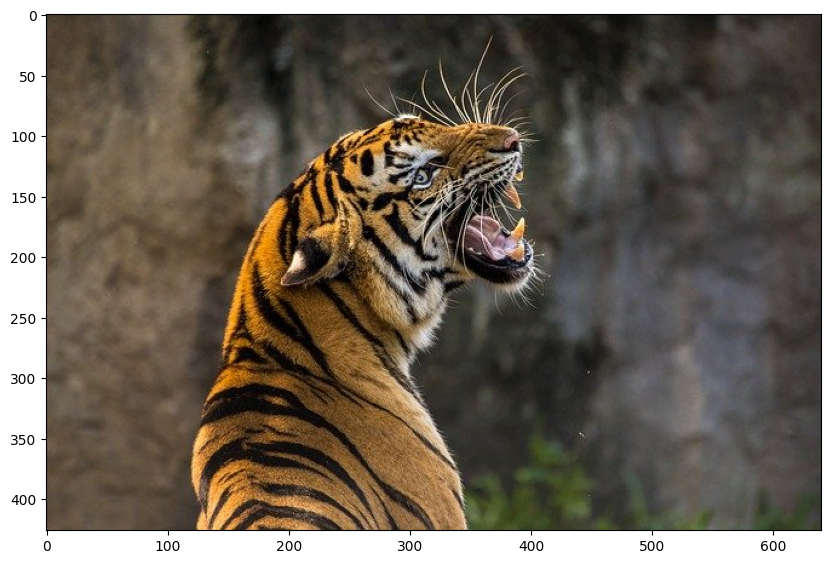

In [6]:
tiger_img = cv2.imread('data/images/image1.jpg')
plt.figure(figsize=(10, 10))
plt.imshow(tiger_img[:, :, ::-1])

In [7]:
blob = cv2.dnn.blobFromImage(
    image = tiger_img,
    scalefactor = 0.017,
    size = (224, 224),
    mean = (104, 117, 123),
    swapRB = False,
    crop = False
)

model.setInput(blob)

In [8]:
outputs = model.forward()
final_outputs = outputs[0]

In [11]:
final_outputs = final_outputs.reshape(1000, 1)

label_id = np.argmax(final_outputs)

probs = np.exp(final_outputs) / np.sum(np.exp(final_outputs))

print(probs[:10])
print('Max Probability', np.max(probs))

[[2.1499585e-10]
 [4.0102194e-10]
 [4.2768619e-10]
 [3.2427300e-10]
 [1.6526440e-11]
 [1.6457802e-11]
 [1.5199699e-11]
 [4.4728008e-09]
 [5.0410902e-09]
 [1.1915434e-09]]
Max Probability 0.9372195


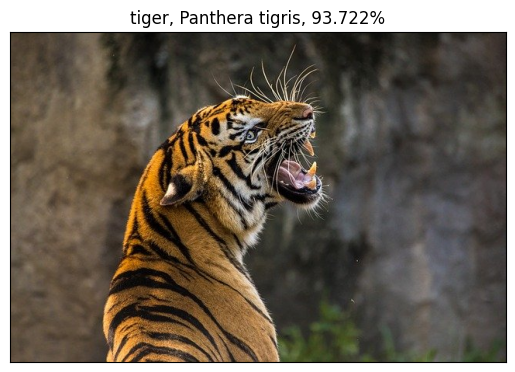

In [12]:
final_prob = np.max(probs) * 100.0

# Map the max confidence to the class label names.
out_name = class_names[label_id]
out_text = f"{out_name}, {final_prob:.3f}%"

# Display the image, best matched classification, and confidence.
plt.imshow(tiger_img[:, :, ::-1])
plt.title(out_text)
plt.xticks([]), plt.yticks([])
plt.show()

In [13]:
def classify(img):
    image = img.copy()
    # Create blob from image.
    blob = cv2.dnn.blobFromImage(image=image, scalefactor=0.01, size=(224, 224), mean=(104, 117, 123))
    # Set the input blob for the neural network.
    model.setInput(blob)
    # Forward pass image blog through the model.
    outputs = model.forward()
    
    final_outputs = outputs[0]
    # Make all the outputs 1D.
    final_outputs = final_outputs.reshape(1000, 1)
    # Get the class label.
    label_id = np.argmax(final_outputs)
    # Convert score to probabilities
    probs = np.exp(final_outputs) / np.sum(np.exp(final_outputs))
    # Get the final highest probability
    final_prob = np.max(probs) * 100
    # Map the max confidence to the class label names.
    out_name = class_names[label_id]
    out_text = f"{out_name}, {final_prob:.3f}%"
    return out_text

Classifying data/images\image1.jpg
Classifying data/images\image2.jpg
Classifying data/images\image3.jpg
Classifying data/images\image4.jpg
Classifying data/images\image5.jpg
Classifying data/images\image6.jpg


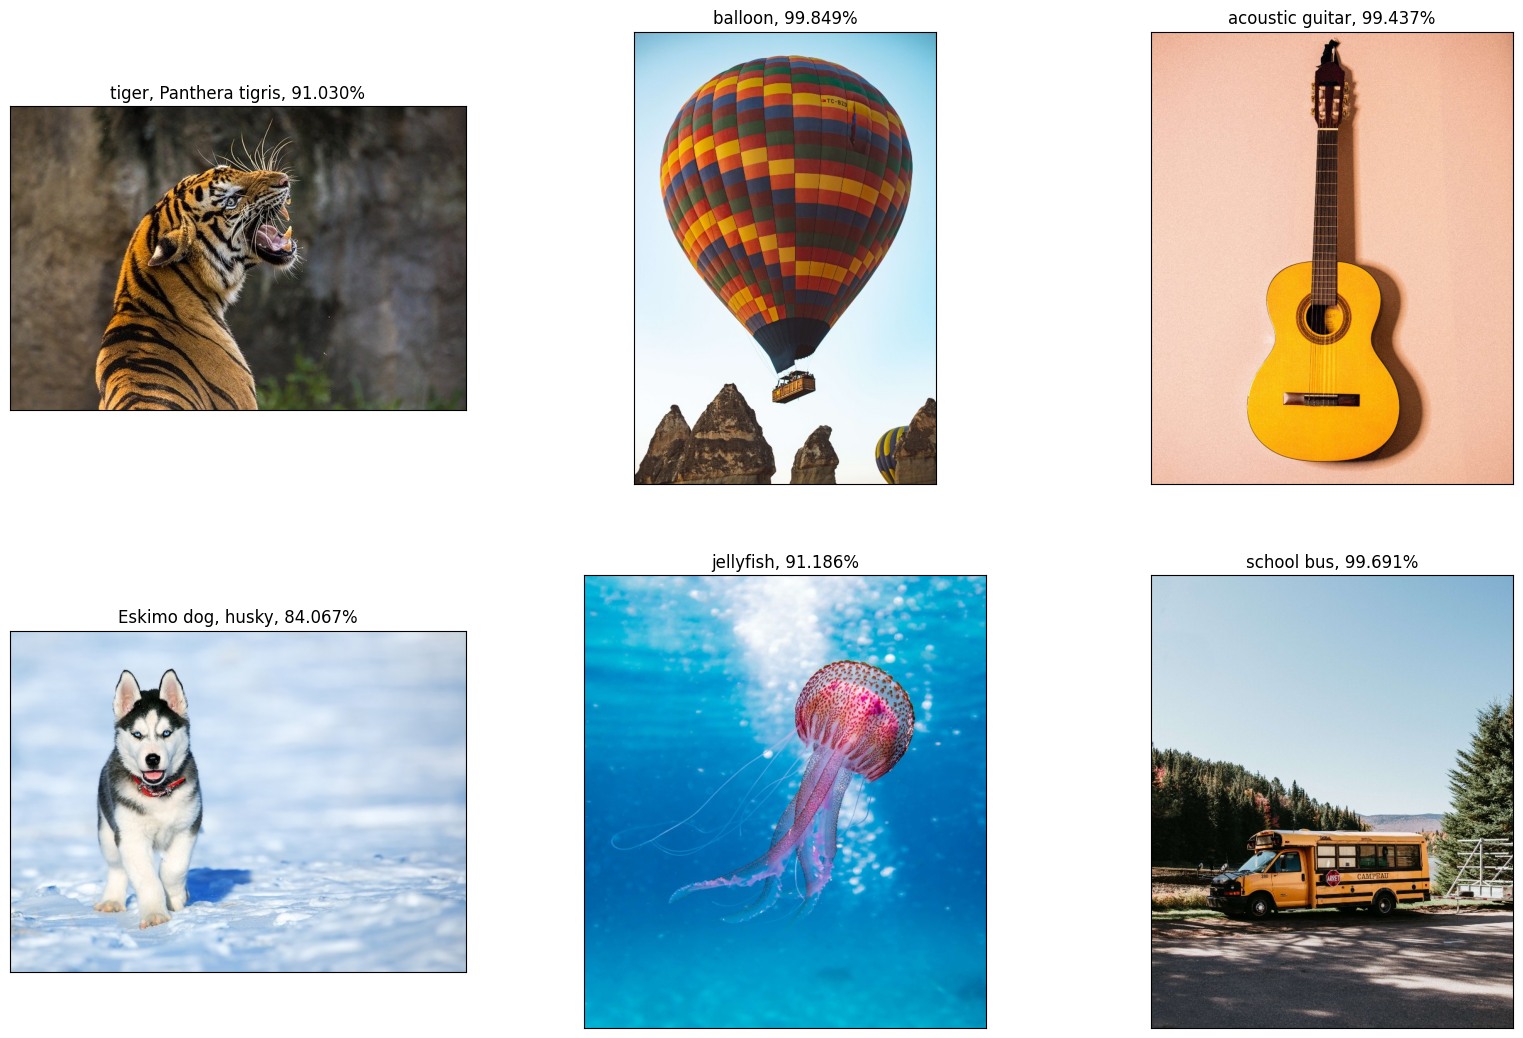

In [17]:
import glob

images = []
imageclasses = []
for img_path in glob.glob('data/images/*.jpg'):
    img = cv2.imread(img_path)
    images.append(img)
    print("Classifying "+img_path)
    imageclasses.append(classify(img))

plt.figure(figsize=(20, 20))

plot_count = int(len(images) / 3) + 1
for i, image in enumerate(images):
    plt.subplot(plot_count, 3, i + 1)
    plt.imshow(image[:, :, ::-1])
    plt.title(imageclasses[i])
    plt.xticks([])
    plt.yticks([])